# <u>From phase space to Krylov space, one shell at a time</u>

# <i>Project notebook</i>

We begin this notebook by importing the necessary packages and modules.

In [1]:
from KrylovQuantumClassical import util
from KrylovQuantumClassical.Hamiltonian import Hamiltonian
from KrylovQuantumClassical.LMG import LMG
from KrylovQuantumClassical.FP import FP

import numpy as np
import matplotlib.pyplot as plt

/Users/nicolasdero/Desktop/KrylovQuantumClassical/KrylovQuantumClassical/LMG.py:187: SyntaxWarning: invalid escape sequence '\h'
  This function constructs the parity operator of the LMG model in the spin-S representation, which is given by $\hat{U} = \exp(-i \pi \hat{S}_x)$.
/Users/nicolasdero/Desktop/KrylovQuantumClassical/KrylovQuantumClassical/FP.py:168: SyntaxWarning: invalid escape sequence '\h'
  This function constructs the parity operator of the FP model in the spin-(L, L) representation (L must be integer), which is given by $\hat{U} = \exp(-i \pi (\hat{L}_z + \hat{M}_z))$.
/Users/nicolasdero/Desktop/KrylovQuantumClassical/KrylovQuantumClassical/FP.py:212: SyntaxWarning: invalid escape sequence '\h'
  Its action on the basis states of the spin-(L, L) representation, $\hat{U}_2\ket{m_1,m_2}=\ket{m_2,m_1}$, where -L <= m1, m2 <= L.


## <span style="color:orange">1.  The LMG and FP models</span>

<span><i>In this section, $\textcolor{red}{bla bla}$.</i></span>

We now compute the densiy of states (DOE) for the LMG model in both regimes $h<J$ and $h>J$.

In [3]:
LMG_system_1 = LMG(0.5, 1.0, 1000)
LMG_system_2 = LMG(2.0, 1.0, 1000)

H_LMG_1  =  LMG_system_1.build_intensive()
H_LMG_2  =  LMG_system_2.build_intensive()

E_LMG_1, E_grid_1, rho_1 = LMG_system_1.compute_DOE()
E_LMG_2, E_grid_2, rho_2 = LMG_system_2.compute_DOE()

hist_1, edges_1 = np.histogram(E_LMG_1, bins = 75, density = True)
centers_1 = 0.5 * (edges_1[:-1] + edges_1[1:])
hist_2, edges_2 = np.histogram(E_LMG_2, bins = 75, density = True)
centers_2 = 0.5 * (edges_2[:-1] + edges_2[1:])

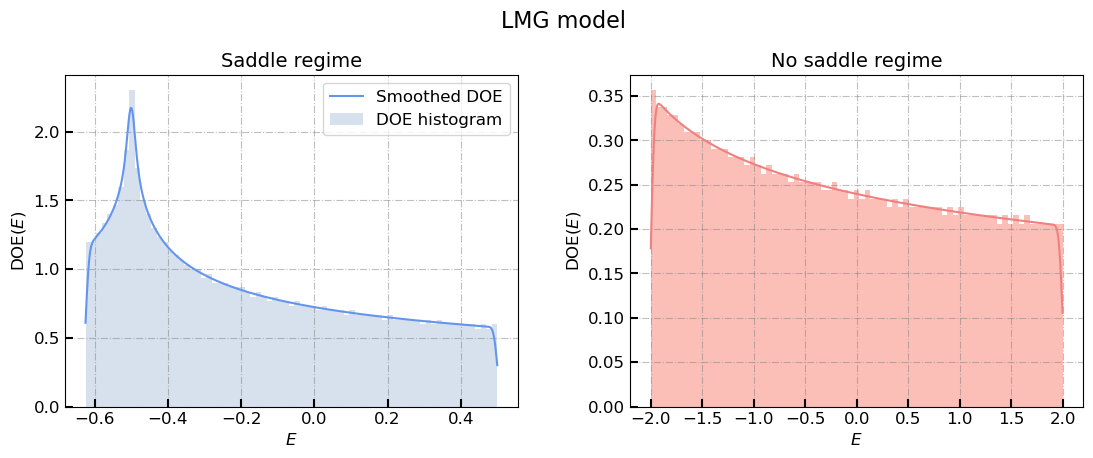

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))
fig.tight_layout(pad = 5.0)

fig.suptitle("LMG model", fontsize=16)
ax1.set_title('Saddle regime', fontsize = 14)
ax2.set_title('No saddle regime', fontsize = 14)

ax1.set_xlabel(r'$E$', fontsize = 12)
ax1.set_ylabel(r'DOE($E$)', fontsize = 12)
ax2.set_xlabel(r'$E$', fontsize = 12)
ax2.set_ylabel(r'DOE($E$)', fontsize = 12)

ax1.grid(True, linestyle = '-.', which = 'both')
ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax2.grid(True, linestyle = '-.', which = 'both')
ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

ax1.plot(E_grid_1, rho_1, color = 'cornflowerblue', label = 'Smoothed DOE')
ax1.bar(centers_1, hist_1, width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOE histogram')
ax2.plot(E_grid_2, rho_2, color='lightcoral', label = 'Smoothed DOE')
ax2.bar(centers_2, hist_2, width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5, label = 'DOE histogram')

ax1.legend(fontsize = 'large')

plt.show()

In [5]:
FP_system_1 = FP(0.0, 20)
FP_system_2 = FP(0.9, 20)

H_FP_1  =  FP_system_1.build_intensive()
H_FP_2  =  FP_system_2.build_intensive()

E_FP_1, E_grid_1, rho_1 = FP_system_1.compute_DOE()
E_FP_2, E_grid_2, rho_2 = FP_system_2.compute_DOE()

hist_1, edges_1 = np.histogram(E_FP_1, bins = 75, density = True)
centers_1 = 0.5 * (edges_1[:-1] + edges_1[1:])
hist_2, edges_2 = np.histogram(E_FP_2, bins = 75, density = True)
centers_2 = 0.5 * (edges_2[:-1] + edges_2[1:])

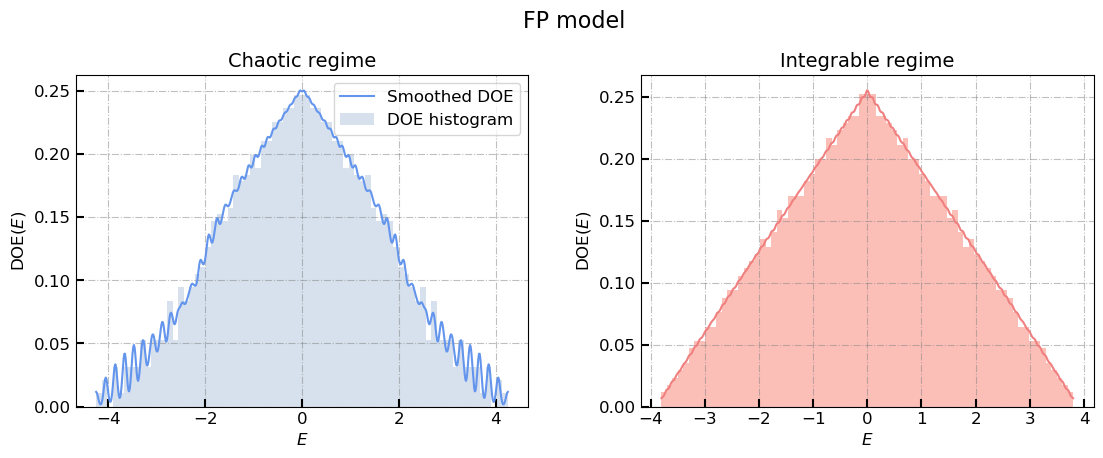

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))
fig.tight_layout(pad = 5.0)

fig.suptitle("FP model", fontsize=16)
ax1.set_title('Chaotic regime', fontsize = 14)
ax2.set_title('Integrable regime', fontsize = 14)

ax1.set_xlabel(r'$E$', fontsize = 12)
ax1.set_ylabel(r'DOE($E$)', fontsize = 12)
ax2.set_xlabel(r'$E$', fontsize = 12)
ax2.set_ylabel(r'DOE($E$)', fontsize = 12)

ax1.grid(True, linestyle = '-.', which = 'both')
ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax2.grid(True, linestyle = '-.', which = 'both')
ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

ax1.plot(E_grid_1, rho_1, color = 'cornflowerblue', label = 'Smoothed DOE')
ax1.bar(centers_1, hist_1, width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOE histogram')
ax2.plot(E_grid_2, rho_2, color='lightcoral', label = 'Smoothed DOE')
ax2.bar(centers_2, hist_2, width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5, label = 'DOE histogram')

ax1.legend(fontsize = 'large')

plt.show()

Since the ground state is degenerate in the regime $h<J$, it is more convenient to illustrate the quantum phase transition (QPT) by plotting the magnetization of the operator $\hat{s}_z^2$ in the ground state as a function of $h$. The magnetization is defined as $m = \langle \psi_0 | \hat{s}_z^2 | \psi_0 \rangle$, where $|\psi_0\rangle$ is the ground state of the system. In the thermodynamic limit, we expect a sharp transition in the magnetization at the critical point $h=J$. For finite systems, this transition will be smoothed out, but we should still see a significant change in the magnetization around the critical point. The excited state quantum phase transition (ESQPT) can be illustrated by plotting the magnetization of the operator $\hat{s}_z^2$ in the first excited state as a function of $h$.

In [7]:
h_list = np.linspace(0.0, 2, 101)
m_list_QPT_LMG = np.zeros(len(h_list), dtype = complex)
m_list_ESQPT_LMG = np.zeros(len(h_list), dtype = complex)

S = 200
Sx, Sy, Sz = util.spin_operators(S)

for i, h in enumerate(h_list):
    LMG_system = LMG(h, 1.0, S)
    LMG_system.build_intensive()
    m_list_QPT_LMG[i] = LMG_system.magnetization(operator = Sz @ Sz / S ** 2)
    m_list_ESQPT_LMG[i] = LMG_system.magnetization(level = 2, operator = Sz @ Sz / S ** 2)

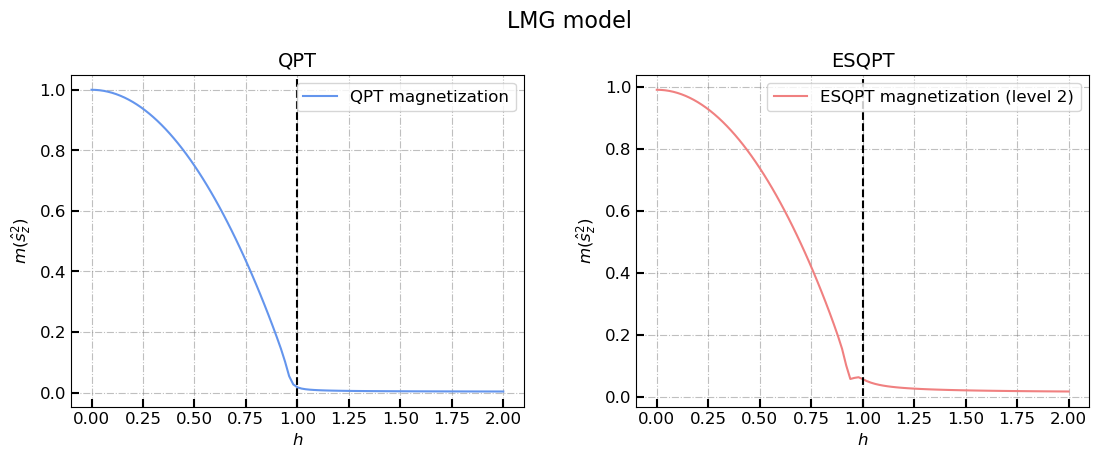

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))
fig.tight_layout(pad = 5.0)

fig.suptitle("LMG model", fontsize=16)
ax1.set_title('QPT', fontsize = 14)
ax2.set_title('ESQPT', fontsize = 14)

ax1.set_xlabel(r'$h$', fontsize = 12)
ax1.set_ylabel(r'$m(\hat{s}_z^2)$', fontsize = 12)
ax2.set_xlabel(r'$h$', fontsize = 12)
ax2.set_ylabel(r'$m(\hat{s}_z^2)$', fontsize = 12)

ax1.grid(True, linestyle = '-.', which = 'both')
ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax2.grid(True, linestyle = '-.', which = 'both')
ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

ax1.plot(h_list, np.real(m_list_QPT_LMG), color = 'cornflowerblue', label = 'QPT magnetization')
ax2.plot(h_list, np.real(m_list_ESQPT_LMG), color = 'lightcoral', label = 'ESQPT magnetization (level 2)')

ax1.axvline(x =1, color = 'black', linestyle = '--', linewidth = 1.5)
ax2.axvline(x = 1, color = 'black', linestyle = '--', linewidth = 1.5)

ax1.legend(fontsize = 'large')
ax2.legend(fontsize = 'large')

plt.show()

The idea is similar for the FP model. Here, the order parameter for the ground-state QPT is $\langle \psi_0 | \hat{s}_x \otimes \hat{s}_x | \psi_0 \rangle$. The QPT and ESQPT occur at $\lambda = 3/5$ in the thermodynamic limit.

In [9]:
a_list = np.linspace(-1, 1, 101)
m_list_QPT_FP = np.zeros(len(a_list), dtype = complex)
m_list_ESQPT_FP = np.zeros(len(a_list), dtype = complex)

L = 15

for i, a in enumerate(a_list):
    FP_system = FP(a, L)
    FP_system.build_intensive()
    m_list_QPT_FP[i] = FP_system.magnetization()
    m_list_ESQPT_FP[i] = FP_system.magnetization(level = 2)

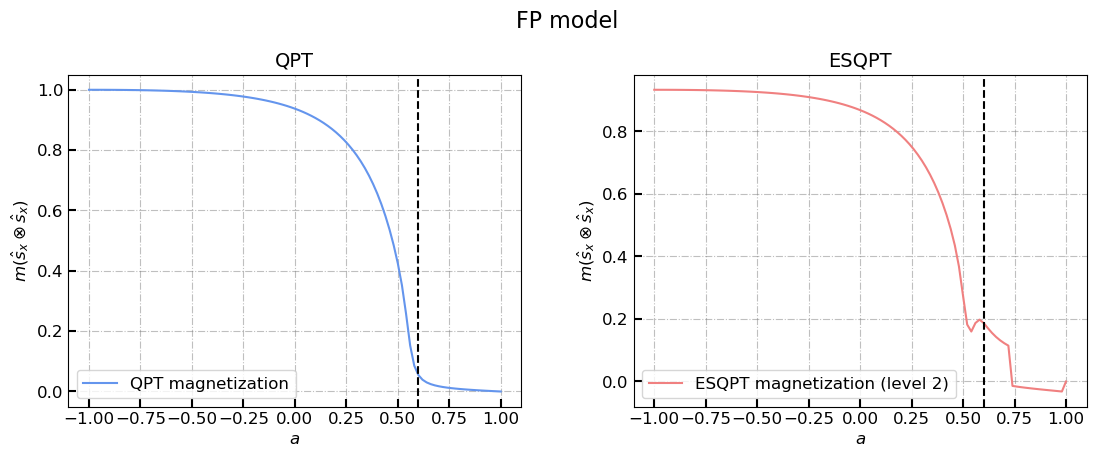

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))
fig.tight_layout(pad = 5.0)

fig.suptitle("FP model", fontsize=16)
ax1.set_title('QPT', fontsize = 14)
ax2.set_title('ESQPT', fontsize = 14)

ax1.set_xlabel(r'$a$', fontsize = 12)
ax1.set_ylabel(r'$m(\hat{s}_x\otimes \hat{s}_x)$', fontsize = 12)
ax2.set_xlabel(r'$a$', fontsize = 12)
ax2.set_ylabel(r'$m(\hat{s}_x\otimes \hat{s}_x)$', fontsize = 12)

ax1.grid(True, linestyle = '-.', which = 'both')
ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax2.grid(True, linestyle = '-.', which = 'both')
ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

ax1.plot(a_list, np.real(m_list_QPT_FP), color = 'cornflowerblue', label = 'QPT magnetization')
ax2.plot(a_list, np.real(m_list_ESQPT_FP), color = 'lightcoral', label = 'ESQPT magnetization (level 2)')

ax1.axvline(x = 3 / 5, color = 'black', linestyle = '--', linewidth = 1.5)
ax2.axvline(x = 3 / 5, color = 'black', linestyle = '--', linewidth = 1.5)

ax1.legend(fontsize = 'large')
ax2.legend(fontsize = 'large')

plt.show()

Exploring quasi-degeneracies in the LMG model.

In [2]:
h_list = np.linspace(0.0, 2, 101)

E_spectrum_minus_list = []
E_spectrum_plus_list = []

for h in h_list:
    LMG_system = LMG(h, 1.0, 10)
    LMG_system.build_intensive()
    E_spectrum_blocks = LMG_system.parity_blocks(True)
    E_spectrum_minus_list.append(E_spectrum_blocks[2])
    E_spectrum_plus_list.append(E_spectrum_blocks[3])

E_spectrum_minus_array = np.array(E_spectrum_minus_list)
E_spectrum_plus_array = np.array(E_spectrum_plus_list)

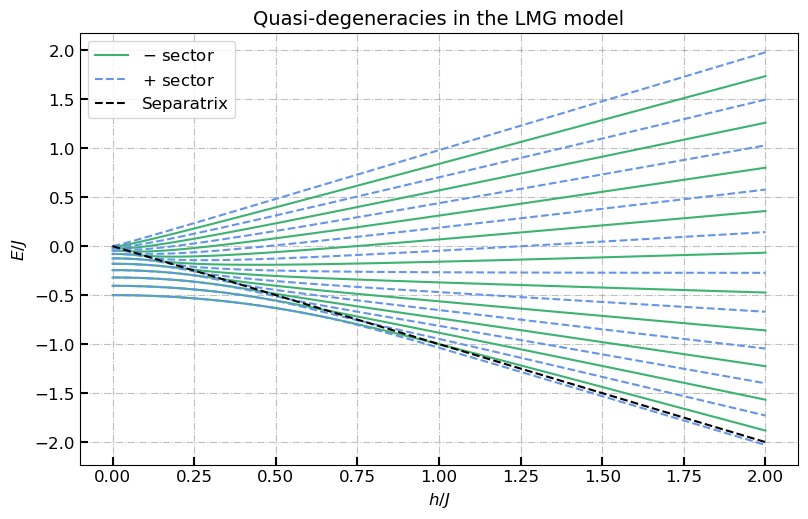

In [3]:
fig, ax = plt.subplots(figsize = (9, 6))
fig.tight_layout(pad = 5.0)

ax.set_title('Quasi-degeneracies in the LMG model', fontsize = 14)

ax.set_xlabel(r'$h/J$', fontsize = 12)
ax.set_ylabel(r'$E/J$', fontsize = 12)

ax.grid(True, linestyle = '-.', which = 'both')
ax.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

for i, x in enumerate(E_spectrum_minus_array.T):
    ax.plot(h_list, x, color = 'mediumseagreen', label = '$-$ sector' if i == 0 else "")

for i, x in enumerate(E_spectrum_plus_array.T):
    ax.plot(h_list, x, color = 'cornflowerblue', linestyle = '--', label = '$+$ sector' if i == 0 else "")

ax.plot(h_list, - h_list, color = 'black', linestyle = '--', linewidth = 1.5, label = 'Separatrix')

ax.legend(fontsize = 'large')

plt.show()

In [4]:
FP_system = FP(0.5, 1)
FP_system.exchange_operator()

array([[1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1]])

In [5]:
FP_system = FP(0.5, 1)
FP_system.build_intensive()
FP_system.parity_blocks()

(array([[-3.        +0.j,  1.        +0.j,  0.        +0.j,
          0.        +0.j],
        [ 1.        +0.j,  0.        +0.j,  1.        +0.j,
          1.41421356+0.j],
        [ 0.        +0.j,  1.        +0.j,  3.        +0.j,
          0.        +0.j],
        [ 0.        +0.j,  1.41421356+0.j,  0.        +0.j,
          0.        +0.j]]),
 array([[0.+0.j]]),
 array([[-2.5+0.j, -1. +0.j],
        [-1. +0.j,  0.5+0.j]]),
 array([[-0.5+0.j, -1. +0.j],
        [-1. +0.j,  2.5+0.j]]))

In [6]:
LMG_system = LMG(1.0, 1.0, 6)
LMG_system.blocks_dimension()

(7, 6)

In [11]:
3.4 % 2

1.4